In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from livelossplot import PlotLossesKerasTF

ModuleNotFoundError: No module named 'livelossplot'

In [4]:
pip install livelossplot

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Load the dataset
file_path = r"D:\quanttrade20260207\MLP_TEST\cancer-data.csv"
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Convert 'diagnosis' into binary format
labelencoder_Y = LabelEncoder()
data['diagnosis'] = labelencoder_Y.fit_transform(data['diagnosis'])

In [4]:
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [5]:
# Drop 'id' column
data.drop(['id'], axis=1, inplace=True)

In [6]:
# Split the dataset into features and target
X = data.drop(['diagnosis'], axis=1)
y = data['diagnosis']

In [7]:
# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import tensorflow as tf

# Build the model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))  # Explicit Input layer
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

In [10]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

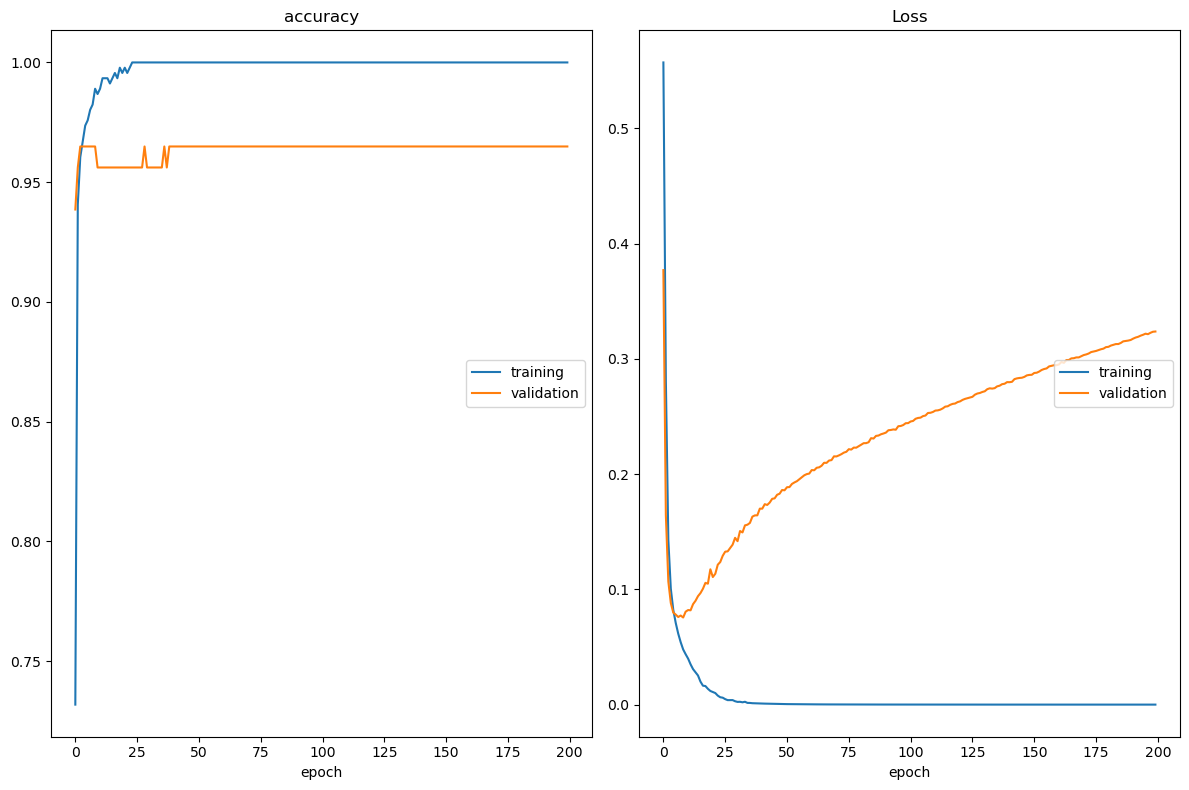

accuracy
	training         	 (min:    0.732, max:    1.000, cur:    1.000)
	validation       	 (min:    0.939, max:    0.965, cur:    0.965)
Loss
	training         	 (min:    0.000, max:    0.557, cur:    0.000)
	validation       	 (min:    0.076, max:    0.377, cur:    0.324)

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 1.3885e-06 - val_accuracy: 0.9649 - val_loss: 0.3237


In [11]:
# Train the model with live plot
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=200, 
                    batch_size=10, 
                    callbacks=[PlotLossesKerasTF()])


In [18]:
# Extracting details from the history object
training_loss = history.history['loss']
training_accuracy = history.history['accuracy']
validation_loss = history.history['val_loss']
validation_accuracy = history.history['val_accuracy']

# Reporting the final performance
print("Final Training Loss: {:.4f}".format(training_loss[-1]))
print("Final Training Accuracy: {:.2f}%".format(training_accuracy[-1] * 100))
print("Final Validation Loss: {:.4f}".format(validation_loss[-1]))
print("Final Validation Accuracy: {:.2f}%".format(validation_accuracy[-1] * 100))


Final Training Loss: 0.0000
Final Training Accuracy: 100.00%
Final Validation Loss: 0.3237
Final Validation Accuracy: 96.49%


In [19]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the results
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9651 - loss: 0.4062
Test Loss: 0.3237
Test Accuracy: 96.49%


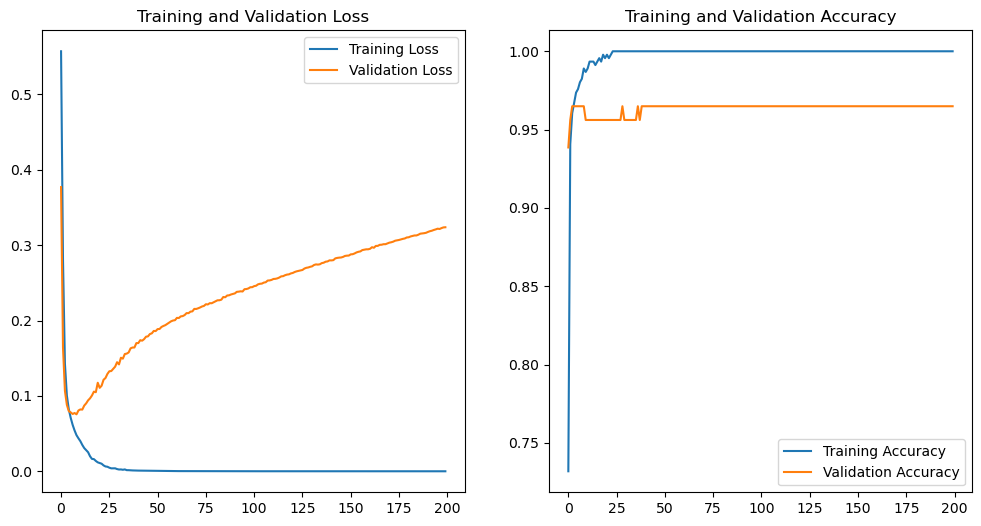

In [20]:
import matplotlib.pyplot as plt

# Plot for loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot for accuracy
plt.subplot(1, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Text(50.722222222222214, 0.5, 'Truth')

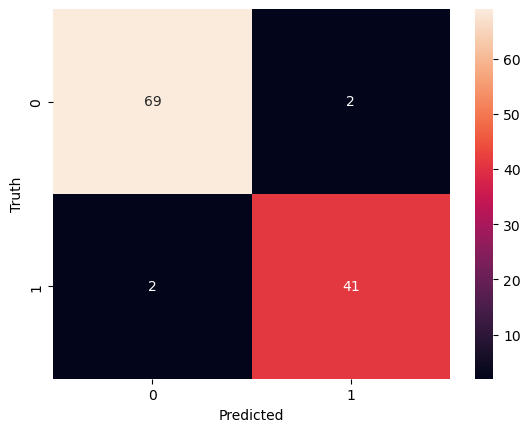

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(X_test) > 0.5
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


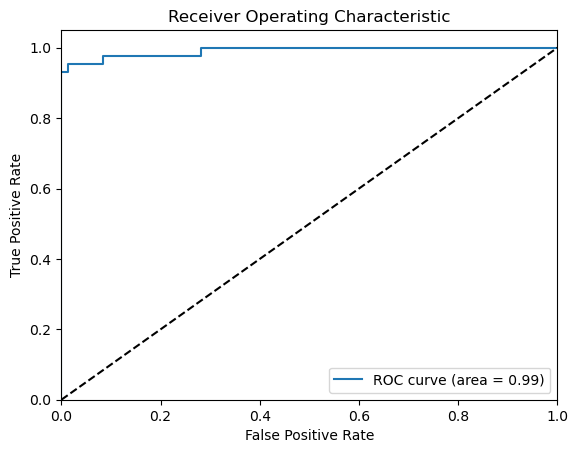

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


- Cross-Validation: To ensure your model's performance is consistent across different subsets of your dataset, consider using cross-validation.

- Hyperparameter Tuning: Experiment with different architectures, learning rates, batch sizes, etc., to see if you can improve the model's performance.

- Feature Importance: Understanding which features are most influential in predicting the outcome can provide valuable insights. This is more complex in neural networks but can be approximated using techniques like permutation importance.

- Error Analysis: Look at specific examples where your model made errors. Understand if there’s a pattern or similarity in these errors.

- Model Explanation Tools: Tools like SHAP (SHapley Additive exPlanations) can help interpret the output of machine learning models and understand the contribution of each feature to the prediction.

- Learning Curves: Analyze the learning curves (training loss vs validation loss over epochs) for signs of overfitting or underfitting.

- Deploying the Model: If your model performs well, you might consider deploying it as a web application or integrating it into a healthcare system for practical use.